# 05 — Two-Stage Model (Regular + Intermittent)

Splits series by zero-rate:
- **Regular** (≤50% zeros) → single LightGBM regressor
- **Intermittent** (>50% zeros) → classifier × regressor

Run `03_model.ipynb` first (needs `lgb_model.txt` for comparison).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import calendar, gc, os, warnings
warnings.filterwarnings("ignore")

## 1. Load Data & Build Features

In [3]:
CACHE_FILE = "df_CA_cache.parquet"
df_CA = pd.read_parquet(CACHE_FILE)

DROP = ["id","d","d_num","state_id","wm_yr_wk","weekday","wday","year",
        "event_name_1","event_name_2","event_type_2","snap_TX","snap_WI"]
df_CA = df_CA.drop(columns=[c for c in DROP if c in df_CA.columns])

DEV_MODE = True
if DEV_MODE:
    df_CA = df_CA[df_CA["store_id"].isin(["CA_1","CA_3"])].reset_index(drop=True)
    cutoff = df_CA["date"].max() - pd.Timedelta(days=730)
    df_CA  = df_CA[df_CA["date"] >= cutoff].reset_index(drop=True)

df_CA = df_CA.sort_values(["item_id","store_id","date"]).reset_index(drop=True)
print(f"df_CA: {df_CA.shape} | {df_CA['date'].min().date()} -> {df_CA['date'].max().date()}")

df_CA: (4457638, 10) | 2014-04-25 -> 2016-04-24


In [4]:
df_CA["sales_log"] = np.log1p(df_CA["sales"].astype("float32")).astype("float32")

grp = df_CA.groupby(["item_id","store_id"], observed=True)["sales_log"]
df_CA["lag_7_log"]  = grp.shift(7).astype("float32")
df_CA["lag_28_log"] = grp.shift(28).astype("float32")
del grp

prev_year = df_CA["date"].dt.year - 1
lookback  = prev_year.map(lambda y: 366 if calendar.isleap(y) else 365)
df_CA["_lag_date"] = (df_CA["date"] - pd.to_timedelta(lookback, unit="D")).astype("datetime64[ms]")
lookup = df_CA[["item_id","store_id","date","sales_log"]].rename(
    columns={"date":"_lag_date","sales_log":"lag_364_log"})
df_CA  = df_CA.merge(lookup, on=["item_id","store_id","_lag_date"], how="left")
df_CA["lag_364_log"] = df_CA["lag_364_log"].astype("float32")
df_CA  = df_CA.drop(columns=["_lag_date"])
del lookup, prev_year, lookback; gc.collect()

gc_flag = ((df_CA["item_id"] != df_CA["item_id"].shift(1)) |
           (df_CA["store_id"] != df_CA["store_id"].shift(1)))
s = df_CA["sales_log"].shift(1); s[gc_flag] = np.nan
df_CA["rolling_mean_7"]  = s.rolling(7,  min_periods=1).mean().astype("float32")
df_CA["rolling_mean_28"] = s.rolling(28, min_periods=1).mean().astype("float32")
df_CA["rolling_std_7"]   = s.rolling(7,  min_periods=1).std().fillna(0).astype("float32")
del s; gc.collect()
sr = df_CA["sales"].shift(1).astype("float32"); sr[gc_flag] = np.nan
df_CA["rolling_zero_count_7"] = (sr==0).rolling(7, min_periods=1).sum().astype("float32")
del sr, gc_flag; gc.collect()

df_CA["day_of_week"]     = df_CA["date"].dt.dayofweek.astype("int8")
df_CA["month"]           = df_CA["date"].dt.month.astype("int8")
df_CA["week_of_year"]    = df_CA["date"].dt.isocalendar().week.astype("int8")
df_CA["is_weekend"]      = (df_CA["date"].dt.dayofweek >= 5).astype("uint8")
df_CA["day_of_month"]    = df_CA["date"].dt.day.astype("int8")
df_CA["event_indicator"] = (df_CA["event_type_1"] != "No_Event").astype("uint8")
df_CA["cat_event"]       = (df_CA["cat_id"].astype(str)+"_"+df_CA["event_type_1"].astype(str)).astype("category")

grp_p = df_CA.groupby(["item_id","store_id"], observed=True)["sell_price"]
p7 = grp_p.shift(7).astype("float32")
df_CA["price_change_7"] = ((df_CA["sell_price"]-p7)/(p7.fillna(1)+1e-8)).astype("float32")
pr28 = grp_p.transform(lambda x: x.shift(1).rolling(28,min_periods=1).mean()).astype("float32")
df_CA["price_ratio_28"] = (df_CA["sell_price"]/(pr28.fillna(1)+1e-8)).astype("float32")
del p7, pr28, grp_p; gc.collect()

df_model = df_CA.dropna(subset=["lag_7_log","lag_28_log","lag_364_log"]).reset_index(drop=True)
del df_CA; gc.collect()
print(f"df_model: {df_model.shape}")

df_model: (2231868, 26)


## 2. Train / Val Split

In [5]:
VAL_DAYS  = 28
max_date  = df_model["date"].max()
val_start = max_date - pd.Timedelta(days=VAL_DAYS - 1)

df_train = df_model[df_model["date"] <  val_start].reset_index(drop=True)
df_val   = df_model[df_model["date"] >= val_start].reset_index(drop=True)

FEATURE_COLS = [
    "lag_7_log","lag_28_log","lag_364_log",
    "rolling_mean_7","rolling_mean_28","rolling_std_7","rolling_zero_count_7",
    "day_of_week","month","week_of_year","is_weekend","day_of_month",
    "event_indicator","cat_event","snap_CA",
    "sell_price","price_change_7","price_ratio_28",
    "store_id","dept_id","cat_id",
]
CAT_COLS = ["store_id","dept_id","cat_id","cat_event"]
for col in CAT_COLS:
    df_train[col] = df_train[col].astype("category")
    df_val[col]   = df_val[col].astype("category")

print(f"Train: {df_train.shape} | Val: {df_val.shape}")

Train: (2061124, 26) | Val: (170744, 26)


## 3. Split Series by Zero-Rate

In [6]:
ZERO_THRESHOLD = 0.50   # series with >50% zero sales = intermittent

zero_rate = (
    df_train.groupby(["item_id","store_id"], observed=True)["sales"]
    .apply(lambda x: (x == 0).mean(), include_groups=False)
    .reset_index().rename(columns={"sales":"zero_rate"})
)
zero_rate["bucket"] = np.where(zero_rate["zero_rate"] > ZERO_THRESHOLD, "intermittent", "regular")

regular_keys     = zero_rate[zero_rate["bucket"] == "regular"][["item_id","store_id"]]
intermittent_keys= zero_rate[zero_rate["bucket"] == "intermittent"][["item_id","store_id"]]

print(f"Regular series:     {len(regular_keys):,}  ({len(regular_keys)/len(zero_rate)*100:.1f}%)")
print(f"Intermittent series:{len(intermittent_keys):,}  ({len(intermittent_keys)/len(zero_rate)*100:.1f}%)")
print(f"Zero-rate threshold: {ZERO_THRESHOLD:.0%}")

Regular series:     2,673  (43.8%)
Intermittent series:3,425  (56.2%)
Zero-rate threshold: 50%


In [7]:
# Filter train/val by bucket
def filter_by_keys(df, keys):
    return df.merge(keys, on=["item_id","store_id"]).reset_index(drop=True)

train_reg  = filter_by_keys(df_train, regular_keys)
train_intr = filter_by_keys(df_train, intermittent_keys)
val_reg    = filter_by_keys(df_val,   regular_keys)
val_intr   = filter_by_keys(df_val,   intermittent_keys)

print(f"Train regular:      {train_reg.shape[0]:,} rows")
print(f"Train intermittent: {train_intr.shape[0]:,} rows")
print(f"Val regular:        {val_reg.shape[0]:,} rows")
print(f"Val intermittent:   {val_intr.shape[0]:,} rows")

Train regular:      903,474 rows
Train intermittent: 1,157,650 rows
Val regular:        74,844 rows
Val intermittent:   95,900 rows


## 4. Model A — Regular Series (Regressor)

In [8]:
params_reg = {
    "objective": "regression", "metric": "rmse",
    "verbosity": -1, "num_leaves": 127,
    "learning_rate": 0.05, "feature_fraction": 0.8,
    "bagging_fraction": 0.8, "bagging_freq": 5,
    "min_child_samples": 20, "lambda_l1": 0.1, "lambda_l2": 0.1, "seed": 42,
}

dtrain_reg = lgb.Dataset(train_reg[FEATURE_COLS], label=train_reg["sales_log"],
                          categorical_feature=CAT_COLS, free_raw_data=False)
dval_reg   = lgb.Dataset(val_reg[FEATURE_COLS],   label=val_reg["sales_log"],
                          categorical_feature=CAT_COLS, reference=dtrain_reg, free_raw_data=False)

print("Training regular series regressor...")
model_reg = lgb.train(
    params_reg, dtrain_reg, num_boost_round=1000,
    valid_sets=[dtrain_reg, dval_reg], valid_names=["train","val"],
    callbacks=[lgb.early_stopping(50, verbose=True), lgb.log_evaluation(100)],
)
del dtrain_reg, dval_reg; gc.collect()
print(f"Best iteration: {model_reg.best_iteration} | Val RMSE: {model_reg.best_score['val']['rmse']:.4f}")

Training regular series regressor...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.593416	val's rmse: 0.598836
[200]	train's rmse: 0.587137	val's rmse: 0.598117
[300]	train's rmse: 0.582969	val's rmse: 0.597849
Early stopping, best iteration is:
[319]	train's rmse: 0.582243	val's rmse: 0.597823
Best iteration: 319 | Val RMSE: 0.5978


## 5. Model B — Intermittent Series (Two-Stage)

### Stage 1: Classifier — Will it sell today?

In [9]:
# Target: 1 if sales > 0, 0 otherwise
train_intr["sale_flag"] = (train_intr["sales"] > 0).astype("int8")
val_intr["sale_flag"]   = (val_intr["sales"]   > 0).astype("int8")

pos_rate = train_intr["sale_flag"].mean()
print(f"Sale rate in intermittent train: {pos_rate:.1%} of rows have a sale")

params_clf = {
    "objective": "binary", "metric": "binary_logloss",
    "verbosity": -1, "num_leaves": 63,
    "learning_rate": 0.05, "feature_fraction": 0.8,
    "bagging_fraction": 0.8, "bagging_freq": 5,
    "min_child_samples": 20, "lambda_l1": 0.1, "lambda_l2": 0.1,
    "scale_pos_weight": (1 - pos_rate) / pos_rate,  # handle class imbalance
    "seed": 42,
}

dtrain_clf = lgb.Dataset(train_intr[FEATURE_COLS], label=train_intr["sale_flag"],
                          categorical_feature=CAT_COLS, free_raw_data=False)
dval_clf   = lgb.Dataset(val_intr[FEATURE_COLS],   label=val_intr["sale_flag"],
                          categorical_feature=CAT_COLS, reference=dtrain_clf, free_raw_data=False)

print("Training intermittent classifier...")
model_clf = lgb.train(
    params_clf, dtrain_clf, num_boost_round=1000,
    valid_sets=[dtrain_clf, dval_clf], valid_names=["train","val"],
    callbacks=[lgb.early_stopping(50, verbose=True), lgb.log_evaluation(100)],
)
del dtrain_clf, dval_clf; gc.collect()
print(f"Best iteration: {model_clf.best_iteration}")

Sale rate in intermittent train: 27.5% of rows have a sale
Training intermittent classifier...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[17]	train's binary_logloss: 0.540522	val's binary_logloss: 0.565573
Best iteration: 17


### Stage 2: Regressor — How much if it sells?

In [10]:
# Train ONLY on rows where a sale occurred
train_nonzero = train_intr[train_intr["sales"] > 0].reset_index(drop=True)
val_nonzero   = val_intr[val_intr["sales"] > 0].reset_index(drop=True)

print(f"Non-zero train rows: {len(train_nonzero):,} / {len(train_intr):,} ({len(train_nonzero)/len(train_intr):.1%})")

params_qty = {
    "objective": "regression", "metric": "rmse",
    "verbosity": -1, "num_leaves": 63,
    "learning_rate": 0.05, "feature_fraction": 0.8,
    "bagging_fraction": 0.8, "bagging_freq": 5,
    "min_child_samples": 10, "lambda_l1": 0.1, "lambda_l2": 0.1, "seed": 42,
}

dtrain_qty = lgb.Dataset(train_nonzero[FEATURE_COLS], label=train_nonzero["sales_log"],
                          categorical_feature=CAT_COLS, free_raw_data=False)
dval_qty   = lgb.Dataset(val_nonzero[FEATURE_COLS],   label=val_nonzero["sales_log"],
                          categorical_feature=CAT_COLS, reference=dtrain_qty, free_raw_data=False)

print("Training intermittent quantity regressor...")
model_qty = lgb.train(
    params_qty, dtrain_qty, num_boost_round=1000,
    valid_sets=[dtrain_qty, dval_qty], valid_names=["train","val"],
    callbacks=[lgb.early_stopping(50, verbose=True), lgb.log_evaluation(100)],
)
del dtrain_qty, dval_qty; gc.collect()
print(f"Best iteration: {model_qty.best_iteration}")

Non-zero train rows: 318,132 / 1,157,650 (27.5%)
Training intermittent quantity regressor...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.312742	val's rmse: 0.327176
[200]	train's rmse: 0.308527	val's rmse: 0.326703
Early stopping, best iteration is:
[248]	train's rmse: 0.306866	val's rmse: 0.326618
Best iteration: 248


## 6. Combine Predictions

In [11]:
# Regular: standard regressor
pred_reg = np.expm1(model_reg.predict(val_reg[FEATURE_COLS])).clip(0)

# Intermittent: P(sale) × E(qty | sale)
p_sale   = model_clf.predict(val_intr[FEATURE_COLS])          # probability [0,1]
qty_given_sale = np.expm1(model_qty.predict(val_intr[FEATURE_COLS])).clip(0)
pred_intr = p_sale * qty_given_sale

# Save models
model_reg.save_model("lgb_two_stage_regular.txt")
model_clf.save_model("lgb_two_stage_classifier.txt")
model_qty.save_model("lgb_two_stage_quantity.txt")

print(f"Regular predictions:     {len(pred_reg):,} rows | mean={pred_reg.mean():.3f}")
print(f"Intermittent predictions:{len(pred_intr):,} rows | mean={pred_intr.mean():.3f}")
print(f"  P(sale) mean:          {p_sale.mean():.3f}")
print(f"  E(qty|sale) mean:      {qty_given_sale.mean():.3f}")
print("Models saved.")

Regular predictions:     74,844 rows | mean=2.663
Intermittent predictions:95,900 rows | mean=0.656
  P(sale) mean:          0.404
  E(qty|sale) mean:      1.523
Models saved.


## 7. Evaluate — Two-Stage vs Single Model

In [12]:
def compute_rmsse(df_train_subset, df_val_subset, val_pred):
    scale_dict = {}
    for (it,st), g in df_train_subset.groupby(["item_id","store_id"], observed=True):
        v = g.sort_values("date")["sales"].values.astype(float)
        scale_dict[(str(it),str(st))] = max(np.mean(np.diff(v)**2),1e-8) if len(v)>1 else 1e-8
    vc = df_val_subset[["item_id","store_id","sales","cat_id"]].copy()
    vc["pred"] = np.clip(val_pred, 0, None)
    rows = []
    for (it,st), g in vc.groupby(["item_id","store_id"], observed=True):
        sc  = scale_dict.get((str(it),str(st)), 1e-8)
        mse = np.mean((g["sales"].astype(float).values - g["pred"].values)**2)
        rows.append({"item_id":str(it),"store_id":str(st),
                     "cat_id":str(g["cat_id"].iloc[0]),"rmsse":float(np.sqrt(mse/sc))})
    return pd.DataFrame(rows)

rmsse_reg  = compute_rmsse(train_reg,  val_reg,  pred_reg)
rmsse_intr = compute_rmsse(train_intr, val_intr, pred_intr)
rmsse_two_stage = pd.concat([rmsse_reg, rmsse_intr], ignore_index=True)

# Single model baseline (reload lgb_model.txt if available)
if os.path.exists("lgb_model.txt"):
    model_single = lgb.Booster(model_file="lgb_model.txt")
    pred_single_reg  = np.expm1(model_single.predict(val_reg[FEATURE_COLS])).clip(0)
    pred_single_intr = np.expm1(model_single.predict(val_intr[FEATURE_COLS])).clip(0)
    rmsse_single_reg  = compute_rmsse(train_reg,  val_reg,  pred_single_reg)
    rmsse_single_intr = compute_rmsse(train_intr, val_intr, pred_single_intr)
    has_single = True
else:
    has_single = False
    print("lgb_model.txt not found — skipping single-model comparison.")

print("Two-Stage RMSSE:")
print(f"  Regular     — Median: {rmsse_reg['rmsse'].median():.4f} | Mean: {rmsse_reg['rmsse'].mean():.4f}")
print(f"  Intermittent— Median: {rmsse_intr['rmsse'].median():.4f} | Mean: {rmsse_intr['rmsse'].mean():.4f}")
print(f"  Combined    — Median: {rmsse_two_stage['rmsse'].median():.4f} | Mean: {rmsse_two_stage['rmsse'].mean():.4f}")

Two-Stage RMSSE:
  Regular     — Median: 0.6934 | Mean: 0.7144
  Intermittent— Median: 0.7400 | Mean: 72.8778
  Combined    — Median: 0.7174 | Mean: 41.2457


## 8. Results Chart

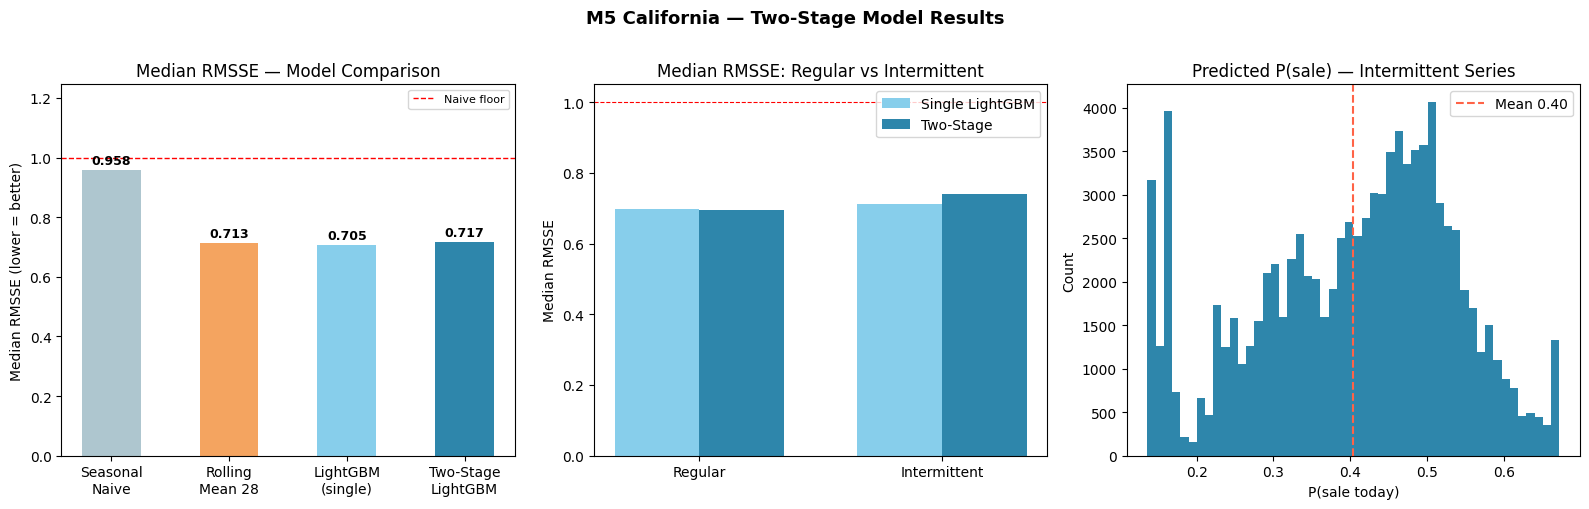

Saved: ca_two_stage_results.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Overall comparison
labels, medians, colors = [], [], []
labels += ["Seasonal\nNaive","Rolling\nMean 28"]
medians += [0.9581, 0.7130]
colors  += ["#aec6cf","#f4a460"]
if has_single:
    combined_single = pd.concat([rmsse_single_reg, rmsse_single_intr])
    labels.append("LightGBM\n(single)")
    medians.append(combined_single["rmsse"].median())
    colors.append("#87ceeb")
labels.append("Two-Stage\nLightGBM")
medians.append(rmsse_two_stage["rmsse"].median())
colors.append("#2e86ab")

bars = axes[0].bar(labels, medians, color=colors, width=0.5)
axes[0].axhline(1.0, color="red", linestyle="--", linewidth=1, label="Naive floor")
for bar, val in zip(bars, medians):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.3f}",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Median RMSSE — Model Comparison")
axes[0].set_ylabel("Median RMSSE (lower = better)")
axes[0].set_ylim(0, max(medians)*1.3)
axes[0].legend(fontsize=8)

# Panel 2: Regular vs Intermittent breakdown
x = np.arange(2); w = 0.35
buckets = ["Regular","Intermittent"]
ts_vals = [rmsse_reg["rmsse"].median(), rmsse_intr["rmsse"].median()]
if has_single:
    sg_vals = [rmsse_single_reg["rmsse"].median(), rmsse_single_intr["rmsse"].median()]
    axes[1].bar(x - w/2, sg_vals, w, color="#87ceeb", label="Single LightGBM")
    axes[1].bar(x + w/2, ts_vals, w, color="#2e86ab", label="Two-Stage")
else:
    axes[1].bar(x, ts_vals, w*1.5, color="#2e86ab", label="Two-Stage")
axes[1].set_xticks(x); axes[1].set_xticklabels(buckets)
axes[1].set_title("Median RMSSE: Regular vs Intermittent")
axes[1].set_ylabel("Median RMSSE")
axes[1].legend()
axes[1].axhline(1.0, color="red", linestyle="--", linewidth=0.8)

# Panel 3: Intermittent — P(sale) distribution
axes[2].hist(p_sale, bins=50, color="#2e86ab", edgecolor="none")
axes[2].axvline(p_sale.mean(), color="tomato", linestyle="--", label=f"Mean {p_sale.mean():.2f}")
axes[2].set_title("Predicted P(sale) — Intermittent Series")
axes[2].set_xlabel("P(sale today)")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.suptitle("M5 California — Two-Stage Model Results", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("ca_two_stage_results.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: ca_two_stage_results.png")

## 9. Summary

In [14]:
two_stage_med = rmsse_two_stage["rmsse"].median()
intr_med_ts   = rmsse_intr["rmsse"].median()
reg_med_ts    = rmsse_reg["rmsse"].median()

print("=" * 58)
print("TWO-STAGE MODEL SUMMARY")
print("=" * 58)
if has_single:
    single_med  = combined_single["rmsse"].median()
    single_intr = rmsse_single_intr["rmsse"].median()
    single_reg  = rmsse_single_reg["rmsse"].median()
    imp_overall = (single_med  - two_stage_med) / single_med  * 100
    imp_intr    = (single_intr - intr_med_ts)   / single_intr * 100
    imp_reg     = (single_reg  - reg_med_ts)    / single_reg  * 100
    print(f"{'Model':<28} {'Median RMSSE':>12}")
    print("-" * 42)
    print(f"{'Single LightGBM':<28} {single_med:>12.4f}")
    print(f"{'Two-Stage (combined)':<28} {two_stage_med:>12.4f}")
    print(f"  Regular series         {reg_med_ts:>12.4f}  ({imp_reg:+.1f}% vs single)")
    print(f"  Intermittent series    {intr_med_ts:>12.4f}  ({imp_intr:+.1f}% vs single)")
    print(f"\nOverall improvement: {imp_overall:+.1f}%")
else:
    print(f"Two-Stage Median RMSSE: {two_stage_med:.4f}")
    print(f"  Regular:     {reg_med_ts:.4f}")
    print(f"  Intermittent:{intr_med_ts:.4f}")
print("=" * 58)
pct_above1 = (rmsse_intr["rmsse"] > 1.0).mean() * 100
print(f"\nIntermittent series still worse than naive: {pct_above1:.1f}%")

TWO-STAGE MODEL SUMMARY
Model                        Median RMSSE
------------------------------------------
Single LightGBM                    0.7054
Two-Stage (combined)               0.7174
  Regular series               0.6934  (+0.8% vs single)
  Intermittent series          0.7400  (-3.9% vs single)

Overall improvement: -1.7%

Intermittent series still worse than naive: 20.9%


## 10. Intermittent Feature Analysis

### 10a. Current Feature Importance — Classifier & Quantity Regressor

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model_, title in [
    (axes[0], model_clf, "Classifier — P(sale today)"),
    (axes[1], model_qty, "Quantity Regressor — E(qty | sale)"),
]:
    imp = pd.DataFrame({
        "feature":    model_.feature_name(),
        "importance": model_.feature_importance(importance_type="gain"),
    }).sort_values("importance", ascending=False).head(15)
    ax.barh(imp["feature"][::-1], imp["importance"][::-1], color="#2e86ab")
    ax.set_title(title)
    ax.set_xlabel("Gain")

plt.suptitle("Feature Importance — Intermittent Series Models", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("ca_intermittent_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: ca_intermittent_importance.png")

### 10b. New Intermittency-Specific Features

Current features treat all series the same. Intermittent demand needs features
that encode the **demand pattern** — not just the level.

| Feature | What it captures | Why it helps |
|---|---|---|
| `days_since_last_sale` | How many days since last non-zero sale | Core of Croston's method — models demand interval |
| `last_nonzero_qty` | Quantity on the most recent sale | Demand size component of Croston's |
| `demand_freq_28` | % of last 28 days with a sale | Smoother version of rolling_zero_count |
| `rolling_zero_count_28` | Zero days in last 28 (longer window) | More stable intermittency estimate |
| `streak_zeros` | Consecutive zeros before today | Captures demand run-length |
| `avg_nonzero_qty_28` | Mean sale size over last 28 non-zero days | Expected size when demand occurs |

In [ ]:
print("Adding intermittency features to df_model...")

# Sort guarantee
df_model_sorted = df_model.sort_values(["item_id","store_id","date"]).reset_index(drop=True)

grp = df_model_sorted.groupby(["item_id","store_id"], observed=True)

# 1. days_since_last_sale — days elapsed since the most recent non-zero sale
def days_since_last(x):
    result = np.full(len(x), np.nan, dtype="float32")
    last   = np.nan
    for i, (idx, row) in enumerate(x.items()):
        if not np.isnan(last):
            result[i] = i - last
        if row > 0:
            last = i
    return pd.Series(result, index=x.index)

df_model_sorted["days_since_last_sale"] = grp["sales"].transform(days_since_last).astype("float32")

# 2. last_nonzero_qty — quantity on the most recent sale (Croston demand size)
def last_nonzero(x):
    result = np.full(len(x), np.nan, dtype="float32")
    last_q = np.nan
    for i, (idx, val) in enumerate(x.items()):
        result[i] = last_q
        if val > 0:
            last_q = float(val)
    return pd.Series(result, index=x.index)

df_model_sorted["last_nonzero_qty"] = grp["sales"].transform(last_nonzero).astype("float32")

# 3. demand_freq_28 — proportion of last 28 days with a sale (shift to avoid leakage)
gc_flag = ((df_model_sorted["item_id"] != df_model_sorted["item_id"].shift(1)) |
           (df_model_sorted["store_id"] != df_model_sorted["store_id"].shift(1)))
s_raw = df_model_sorted["sales"].shift(1).astype("float32"); s_raw[gc_flag] = np.nan
df_model_sorted["demand_freq_28"]     = (s_raw > 0).rolling(28, min_periods=1).mean().astype("float32")
df_model_sorted["rolling_zero_count_28"] = (s_raw == 0).rolling(28, min_periods=1).sum().astype("float32")
del s_raw

# 4. avg_nonzero_qty_28 — mean sale qty over last 28 days (zeros excluded)
def rolling_nonzero_mean(x, w=28):
    shifted = x.shift(1)
    return shifted.where(shifted > 0).rolling(w, min_periods=1).mean()

df_model_sorted["avg_nonzero_qty_28"] = grp["sales"].transform(
    lambda x: rolling_nonzero_mean(x)
).astype("float32")

# 5. streak_zeros — consecutive zero days immediately before today
def zero_streak(x):
    result = np.zeros(len(x), dtype="float32")
    streak = 0
    for i, (idx, val) in enumerate(x.shift(1).items()):
        if np.isnan(val):
            streak = 0
        elif val == 0:
            streak += 1
        else:
            streak = 0
        result[i] = streak
    return pd.Series(result, index=x.index)

df_model_sorted["streak_zeros"] = grp["sales"].transform(zero_streak).astype("float32")

del gc_flag, grp; gc.collect()

NEW_FEATURES = ["days_since_last_sale","last_nonzero_qty","demand_freq_28",
                "rolling_zero_count_28","avg_nonzero_qty_28","streak_zeros"]

print(f"Added {len(NEW_FEATURES)} new features")
print("Null counts (expected for early rows):")
print(df_model_sorted[NEW_FEATURES].isnull().sum().to_string())
print(f"Memory: {df_model_sorted.memory_usage(deep=True).sum()/1e6:.1f} MB")

### 10c. Retrain Intermittent Models with New Features

In [ ]:
# Rebuild splits with new features
df_model_v2 = df_model_sorted.dropna(subset=NEW_FEATURES).reset_index(drop=True)
print(f"df_model_v2: {df_model_v2.shape} (dropped rows with null new features)")

val_start_v2  = df_model_v2["date"].max() - pd.Timedelta(days=VAL_DAYS - 1)
df_train_v2   = df_model_v2[df_model_v2["date"] <  val_start_v2].reset_index(drop=True)
df_val_v2     = df_model_v2[df_model_v2["date"] >= val_start_v2].reset_index(drop=True)

zero_rate_v2 = (
    df_train_v2.groupby(["item_id","store_id"], observed=True)["sales"]
    .apply(lambda x: (x==0).mean(), include_groups=False)
    .reset_index().rename(columns={"sales":"zero_rate"})
)
reg_keys_v2  = zero_rate_v2[zero_rate_v2["zero_rate"] <= ZERO_THRESHOLD][["item_id","store_id"]]
intr_keys_v2 = zero_rate_v2[zero_rate_v2["zero_rate"] >  ZERO_THRESHOLD][["item_id","store_id"]]

train_intr_v2 = filter_by_keys(df_train_v2, intr_keys_v2)
val_intr_v2   = filter_by_keys(df_val_v2,   intr_keys_v2)
train_reg_v2  = filter_by_keys(df_train_v2, reg_keys_v2)
val_reg_v2    = filter_by_keys(df_val_v2,   reg_keys_v2)

FEAT_V2 = FEATURE_COLS + NEW_FEATURES
for col in CAT_COLS:
    for df_ in [train_intr_v2, val_intr_v2, train_reg_v2, val_reg_v2]:
        df_[col] = df_[col].astype("category")

print(f"Intermittent train: {len(train_intr_v2):,} | val: {len(val_intr_v2):,}")
print(f"Regular    train:   {len(train_reg_v2):,} | val: {len(val_reg_v2):,}")

In [ ]:
train_intr_v2["sale_flag"] = (train_intr_v2["sales"] > 0).astype("int8")
val_intr_v2["sale_flag"]   = (val_intr_v2["sales"]   > 0).astype("int8")
train_nonzero_v2 = train_intr_v2[train_intr_v2["sales"] > 0].reset_index(drop=True)

pos_rate_v2 = train_intr_v2["sale_flag"].mean()

# Classifier v2
params_clf["scale_pos_weight"] = (1 - pos_rate_v2) / pos_rate_v2
dtrain_clf2 = lgb.Dataset(train_intr_v2[FEAT_V2], label=train_intr_v2["sale_flag"],
                           categorical_feature=CAT_COLS, free_raw_data=False)
dval_clf2   = lgb.Dataset(val_intr_v2[FEAT_V2],   label=val_intr_v2["sale_flag"],
                           categorical_feature=CAT_COLS, reference=dtrain_clf2, free_raw_data=False)
print("Training classifier v2...")
model_clf_v2 = lgb.train(params_clf, dtrain_clf2, num_boost_round=1000,
    valid_sets=[dtrain_clf2, dval_clf2], valid_names=["train","val"],
    callbacks=[lgb.early_stopping(50, verbose=True), lgb.log_evaluation(100)])
del dtrain_clf2, dval_clf2; gc.collect()

# Quantity regressor v2
dtrain_qty2 = lgb.Dataset(train_nonzero_v2[FEAT_V2], label=train_nonzero_v2["sales_log"],
                           categorical_feature=CAT_COLS, free_raw_data=False)
dval_nz_v2  = val_intr_v2[val_intr_v2["sales"] > 0].reset_index(drop=True)
dval_qty2   = lgb.Dataset(dval_nz_v2[FEAT_V2], label=dval_nz_v2["sales_log"],
                           categorical_feature=CAT_COLS, reference=dtrain_qty2, free_raw_data=False)
print("Training quantity regressor v2...")
model_qty_v2 = lgb.train(params_qty, dtrain_qty2, num_boost_round=1000,
    valid_sets=[dtrain_qty2, dval_qty2], valid_names=["train","val"],
    callbacks=[lgb.early_stopping(50, verbose=True), lgb.log_evaluation(100)])
del dtrain_qty2, dval_qty2; gc.collect()
print("Done.")

### 10d. Compare: With vs Without New Features

In [ ]:
# Regular regressor on v2 data
dtrain_reg2 = lgb.Dataset(train_reg_v2[FEAT_V2], label=train_reg_v2["sales_log"],
                           categorical_feature=CAT_COLS, free_raw_data=False)
dval_reg2   = lgb.Dataset(val_reg_v2[FEAT_V2],   label=val_reg_v2["sales_log"],
                           categorical_feature=CAT_COLS, reference=dtrain_reg2, free_raw_data=False)
model_reg_v2 = lgb.train(params_reg, dtrain_reg2, num_boost_round=1000,
    valid_sets=[dtrain_reg2, dval_reg2], valid_names=["train","val"],
    callbacks=[lgb.early_stopping(50, verbose=True), lgb.log_evaluation(100)])
del dtrain_reg2, dval_reg2; gc.collect()

# Predictions v2
pred_reg_v2  = np.expm1(model_reg_v2.predict(val_reg_v2[FEAT_V2])).clip(0)
p_sale_v2    = model_clf_v2.predict(val_intr_v2[FEAT_V2])
qty_v2       = np.expm1(model_qty_v2.predict(val_intr_v2[FEAT_V2])).clip(0)
pred_intr_v2 = p_sale_v2 * qty_v2

rmsse_reg_v2   = compute_rmsse(train_reg_v2,  val_reg_v2,  pred_reg_v2)
rmsse_intr_v2  = compute_rmsse(train_intr_v2, val_intr_v2, pred_intr_v2)
two_stage_v2   = pd.concat([rmsse_reg_v2, rmsse_intr_v2], ignore_index=True)

# Save v2 models
model_clf_v2.save_model("lgb_clf_v2.txt")
model_qty_v2.save_model("lgb_qty_v2.txt")
model_reg_v2.save_model("lgb_reg_v2.txt")

# Comparison table
print("=" * 62)
print(f"{'Model':<35} {'Reg':>8} {'Intr':>8} {'Combined':>8}")
print("-" * 62)
print(f"{'Two-Stage v1 (no new features)':<35} "
      f"{rmsse_reg['rmsse'].median():>8.4f} "
      f"{rmsse_intr['rmsse'].median():>8.4f} "
      f"{rmsse_two_stage['rmsse'].median():>8.4f}")
print(f"{'Two-Stage v2 (+ intermittent feats)':<35} "
      f"{rmsse_reg_v2['rmsse'].median():>8.4f} "
      f"{rmsse_intr_v2['rmsse'].median():>8.4f} "
      f"{two_stage_v2['rmsse'].median():>8.4f}")
imp = (rmsse_intr["rmsse"].median() - rmsse_intr_v2["rmsse"].median()) / rmsse_intr["rmsse"].median() * 100
print("=" * 62)
print(f"Intermittent improvement from new features: {imp:+.1f}%")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model_, title in [
    (axes[0], model_clf_v2,  "Classifier v2 — P(sale today)"),
    (axes[1], model_qty_v2,  "Quantity Regressor v2 — E(qty | sale)"),
]:
    imp_df = pd.DataFrame({
        "feature":    model_.feature_name(),
        "importance": model_.feature_importance(importance_type="gain"),
    }).sort_values("importance", ascending=False).head(15)
    colors = ["tomato" if f in NEW_FEATURES else "#2e86ab" for f in imp_df["feature"][::-1]]
    ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color=colors)
    ax.set_title(title)
    ax.set_xlabel("Gain")

from matplotlib.patches import Patch
legend = [Patch(color="tomato", label="New feature"), Patch(color="#2e86ab", label="Original feature")]
axes[1].legend(handles=legend, fontsize=8)
plt.suptitle("Feature Importance v2 (red = new intermittency features)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("ca_intermittent_importance_v2.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: ca_intermittent_importance_v2.png")